In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/raddar/chest-xrays-indiana-university/indiana_projections.csv
/kaggle/input/datasets/raddar/chest-xrays-indiana-university/indiana_reports.csv
/kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized/349_IM-1697-2001.dcm.png
/kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized/607_IM-2196-1001.dcm.png
/kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized/2832_IM-1249-2001.dcm.png
/kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized/699_IM-2263-2001.dcm.png
/kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized/1931_IM-0602-2001.dcm.png
/kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized/947_IM-2442-2001.dcm.png
/kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized/2932_IM-1335-1001.dcm.png
/kaggle/input/datasets/raddar/chest-xrays-indiana-univ

In [2]:
import os
import pandas as pd
import numpy as np

from PIL import Image
import matplotlib.pyplot as plt

In [3]:
import os

DATASET_PATH = "/kaggle/input/datasets/raddar/chest-xrays-indiana-university"

print(os.listdir(DATASET_PATH))

['indiana_projections.csv', 'images', 'indiana_reports.csv']


In [4]:
import pandas as pd

reports = pd.read_csv(f"{DATASET_PATH}/indiana_reports.csv")
projections = pd.read_csv(f"{DATASET_PATH}/indiana_projections.csv")

In [5]:
print("Reports Shape :", reports.shape)
print("Projections Shape :", projections.shape)

Reports Shape : (3851, 8)
Projections Shape : (7466, 3)


In [6]:
reports.head()

,uid,MeSH,Problems,image,indication,comparison,findings,impression
0,1,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
2,3,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p..."
3,4,"Pulmonary Disease, Chronic Obstructive;Bullous...","Pulmonary Disease, Chronic Obstructive;Bullous...","PA and lateral views of the chest XXXX, XXXX a...",XXXX-year-old XXXX with XXXX.,None available,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...
4,5,Osteophyte/thoracic vertebrae/multiple/small;T...,Osteophyte;Thickening;Lung,Xray Chest PA and Lateral,Chest and nasal congestion.,NaN,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.


In [7]:
projections.head()

,uid,filename,projection
0,1,1_IM-0001-4001.dcm.png,Frontal
1,1,1_IM-0001-3001.dcm.png,Lateral
2,2,2_IM-0652-1001.dcm.png,Frontal
3,2,2_IM-0652-2001.dcm.png,Lateral
4,3,3_IM-1384-1001.dcm.png,Frontal


In [8]:
print(reports.columns)

Index(['uid', 'MeSH', 'Problems', 'image', 'indication', 'comparison',
       'findings', 'impression'],
      dtype='object')


In [9]:
print(projections.columns)

Index(['uid', 'filename', 'projection'], dtype='object')


In [10]:
reports.isnull().sum()

uid              0
MeSH             0
Problems         0
image            0
indication      86
comparison    1166
findings       514
impression      31
dtype: int64

In [11]:
projections.isnull().sum()

uid           0
filename      0
projection    0
dtype: int64

In [12]:
print("Duplicate Reports :", reports.duplicated().sum())
print("Duplicate Projection Rows :", projections.duplicated().sum())

Duplicate Reports : 0
Duplicate Projection Rows : 0


In [13]:
image_folder = f"{DATASET_PATH}/images/images_normalized"

image_files = os.listdir(image_folder)

print("Total Images :", len(image_files))

Total Images : 7470


In [14]:
from PIL import Image

widths = []
heights = []

for img in image_files:
    image = Image.open(os.path.join(image_folder, img))
    widths.append(image.size[0])
    heights.append(image.size[1])

In [15]:
print("Average Width :", np.mean(widths))
print("Average Height :", np.mean(heights))

print("Minimum Width :", np.min(widths))
print("Maximum Width :", np.max(widths))

print("Minimum Height :", np.min(heights))
print("Maximum Height :", np.max(heights))

Average Width : 2155.766532797858
Average Height : 2220.3657295850066
Minimum Width : 1529
Maximum Width : 2891
Minimum Height : 1760
Maximum Height : 3001


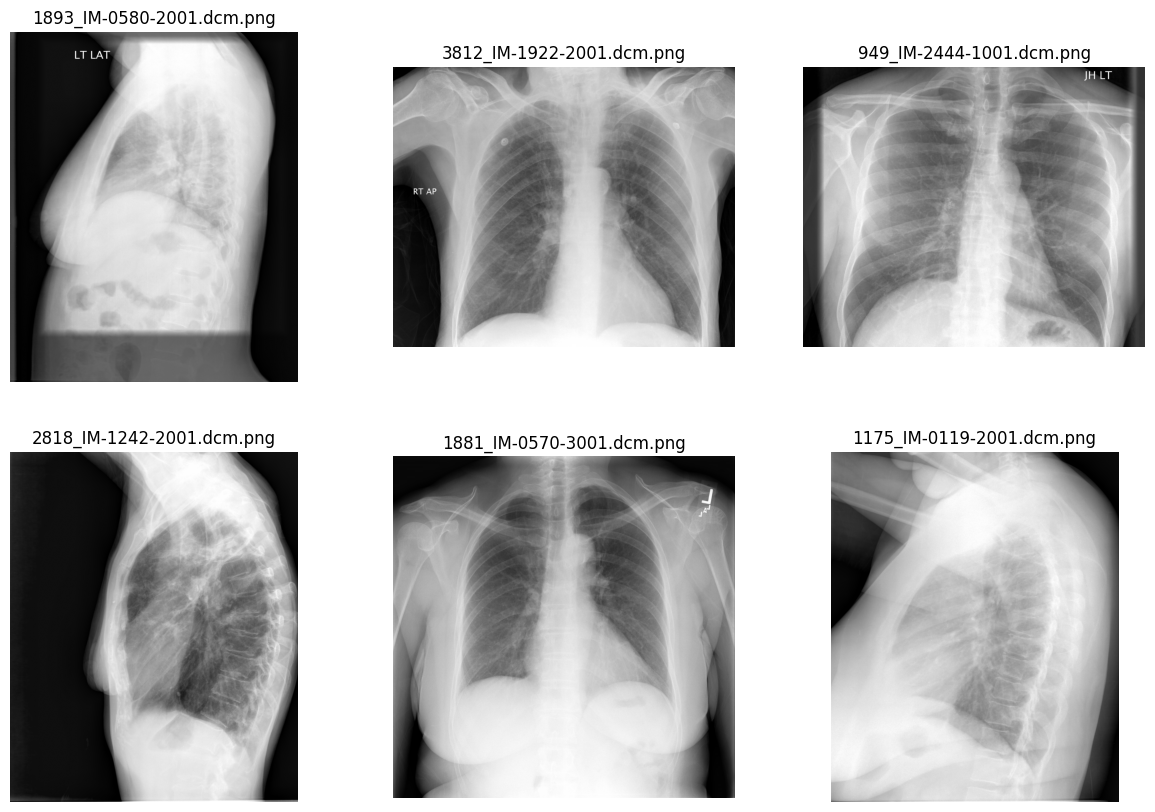

In [16]:
import random

plt.figure(figsize=(15,10))

for i in range(6):

    img = random.choice(image_files)

    image = Image.open(os.path.join(image_folder, img))

    plt.subplot(2,3,i+1)
    plt.imshow(image,cmap='gray')
    plt.title(img)
    plt.axis("off")

plt.show()

In [17]:
reports["report_length"] = reports["findings"].fillna("").apply(len)

reports["report_length"].describe()

count    3851.000000
mean      190.242015
std       118.140421
min         0.000000
25%       119.500000
50%       188.000000
75%       255.000000
max      1054.000000
Name: report_length, dtype: float64

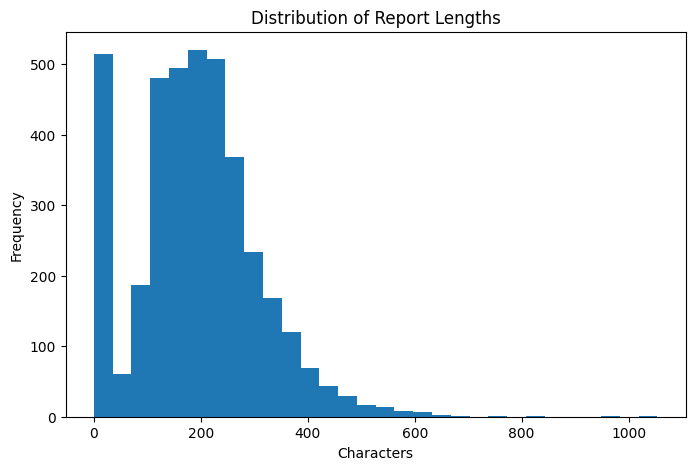

In [18]:
plt.figure(figsize=(8,5))

plt.hist(reports["report_length"], bins=30)

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.title("Distribution of Report Lengths")

plt.show()

In [19]:
for i in range(5):

    print("="*80)

    print("Findings\n")

    print(reports.iloc[i]["findings"])

    print("\nImpression\n")

    print(reports.iloc[i]["impression"])

Findings

The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no XXXX of a pleural effusion. There is no evidence of pneumothorax.

Impression

Normal chest x-XXXX.
Findings

Borderline cardiomegaly. Midline sternotomy XXXX. Enlarged pulmonary arteries. Clear lungs. Inferior XXXX XXXX XXXX.

Impression

No acute pulmonary findings.
Findings

nan

Impression

No displaced rib fractures, pneumothorax, or pleural effusion identified. Well-expanded and clear lungs. Mediastinal contour within normal limits. No acute cardiopulmonary abnormality identified.
Findings

There are diffuse bilateral interstitial and alveolar opacities consistent with chronic obstructive lung disease and bullous emphysema. There are irregular opacities in the left lung apex, that could represent a cavitary lesion in the left lung apex.There are streaky opacities in the right upper lobe, XXXX scarring. The cardiomediastinal sil

In [20]:
projections["projection"].value_counts()

projection
Frontal    3818
Lateral    3648
Name: count, dtype: int64

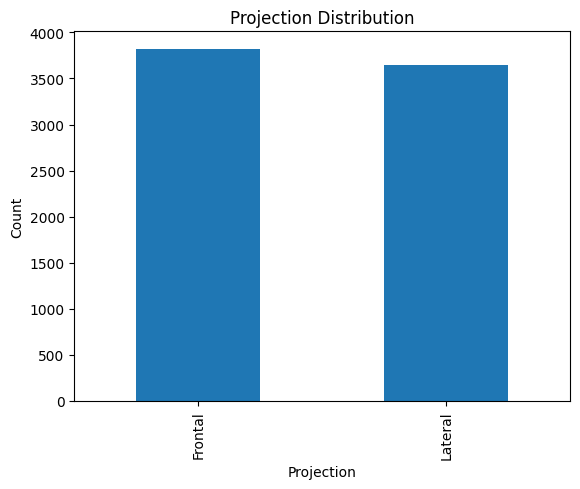

In [21]:
projections["projection"].value_counts().plot(kind="bar")

plt.title("Projection Distribution")

plt.xlabel("Projection")

plt.ylabel("Count")

plt.show()

In [22]:
print("="*50)

print("Dataset Summary")

print("="*50)

print("Total Reports :", len(reports))
print("Total Images :", len(image_files))

print("Average Report Length :", reports["report_length"].mean())

print("Projection Types")

print(projections["projection"].value_counts())

Dataset Summary
Total Reports : 3851
Total Images : 7470
Average Report Length : 190.24201506102312
Projection Types
projection
Frontal    3818
Lateral    3648
Name: count, dtype: int64
